# Tutorial for Data

이 Notebook에는 참가자 분들께서 kspace, image data를 보다 쉽게 분석하실 수 있도록 간단한 시각화 예제를 첨부하였습니다.

## Setup

아래 코드를 실행하기 전, 필요한 module을 import합니다.

In [ ]:
# Set up the environment for running a Python script that uses OpenCV and other libraries
!apt update
!apt install -y libgl1

# Install necessary Python packages
%pip install numpy matplotlib h5py opencv-python

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import cv2

# 데이터 폴더 경로. 본인 환경에 맞게 이 한 줄만 수정하세요.
DATA_DIR = "/root/Data"

## K-space data

kspace data를 담고 있는 h5 file은 아래와 같이 `kspace`, `mask`의 2가지 key를 갖습니다.
- `kspace`: kspace data. (shape: `(slices, coils, height, width)`)
- `mask`: kspace data를 undersampling하기 위한 mask. (shape: `(width, )`)

In [3]:
in_dir = f"{DATA_DIR}/train/kspace/knee_acc4_1.h5"
kspace_f = h5py.File(in_dir)
kspace_f.keys()

<KeysViewHDF5 ['kspace', 'mask']>

In [4]:
kspace = kspace_f['kspace']
mask = kspace_f['mask']
print(kspace.shape, mask.shape)

(23, 15, 640, 368) (368,)


이제 kspace data를 시각화 해보겠습니다.

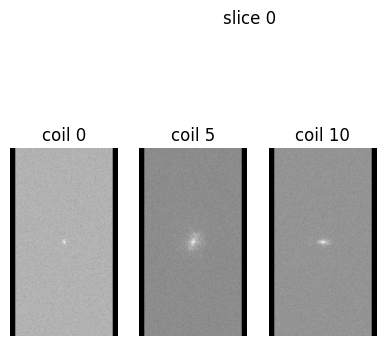

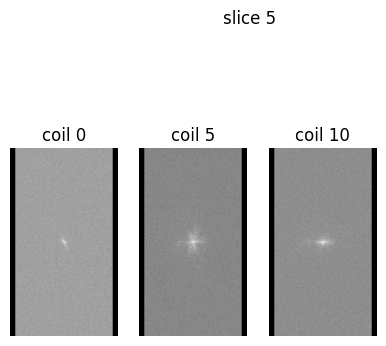

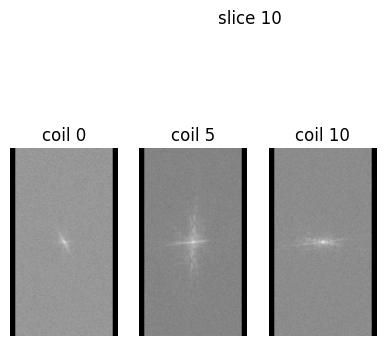

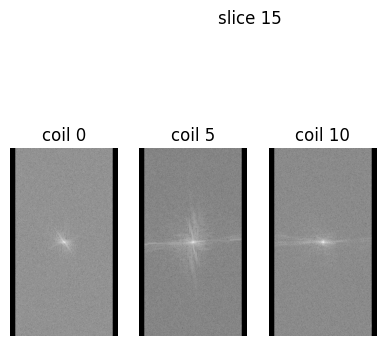

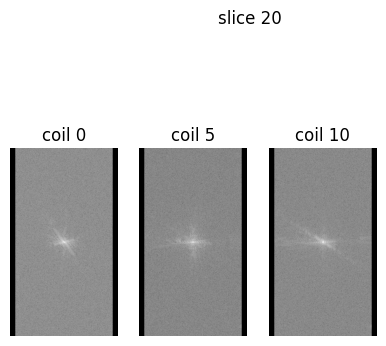

In [5]:
slice_len = kspace.shape[0]
for slice_idx in range(0, slice_len, 5):
    # convert kspace slice to real image
    kspace_slice = kspace[slice_idx]
    kspace_slice = np.log(np.abs(kspace_slice) + 1e-9)

    plt.figure()
    plt.suptitle(f'slice {slice_idx}')
    coil_len = kspace_slice.shape[0]
    for i, coil_idx in enumerate(range(0, coil_len, 5)):
        ax = plt.subplot(1, coil_len // 5 + 1, i + 1)
        plt.title(f'coil {coil_idx}')
        ax.imshow(kspace_slice[coil_idx], cmap='gray')
        plt.axis('off')  # Remove axes for a cleaner look

    plt.show()

위에서 확인하실 수 있듯, 본 challenge에서 다루는 data는 *multi-coil* data입니다. \
그러므로 하나의 slice에 대하여 서로 다른 coil로 얻어진 kspace data가 존재합니다. \
이들에 각각 inverse fourier transform을 취한 뒤, RSS(*root sum squared*) 연산을 취해 하나의 reconstruction image를 얻는 것입니다.

In [6]:
kspace_f.close()

## Image data (knee, acc4)

image data를 담고 있는 h5 file은 아래와 같이 `image_grappa`, `image_input`, `image_label`의 3가지 key를 갖습니다.
- `image_grappa`: _GRAPPA method_*를 사용하여 reconstruct한 image
- `image_input`: undersampled kspace data로부터 얻은 **aliased** image
- `image_label`: fully-sampled kspace data로부터 얻은 **aliasing free** image

각 파일에 대해, 세 이미지의 shape는 모두 `(slices, height, width)` 로 동일합니다. \
(*GRAPPA method에 관해서는 본 Challenge의 youtube channel에 설명 영상이 업로드되어 있습니다.)

In [7]:
in_dir = f"{DATA_DIR}/train/image/knee_acc4_1.h5"
image_f = h5py.File(in_dir)
image_f.keys()

<KeysViewHDF5 ['image_grappa', 'image_input', 'image_label']>

In [8]:
image_grappa = image_f['image_grappa']
image_input = image_f['image_input']
image_label = image_f['image_label']
print(image_grappa.shape, image_input.shape, image_label.shape)

(23, 384, 384) (23, 384, 384) (23, 384, 384)


이제 image data를 시각화 해보겠습니다.

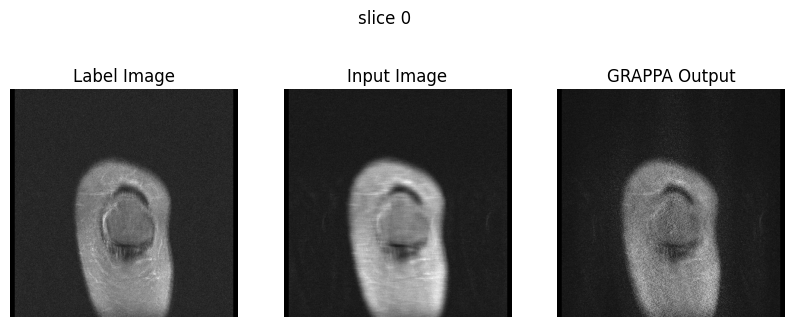

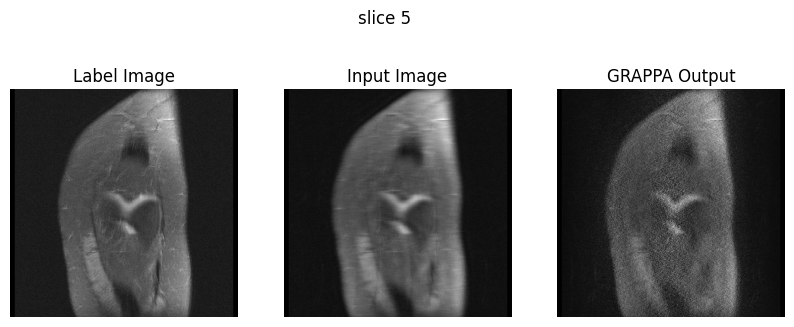

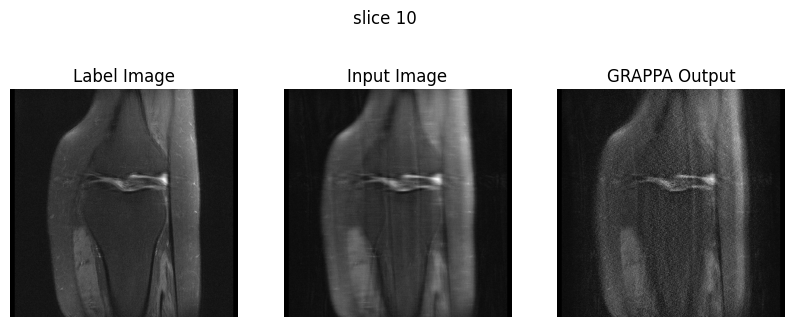

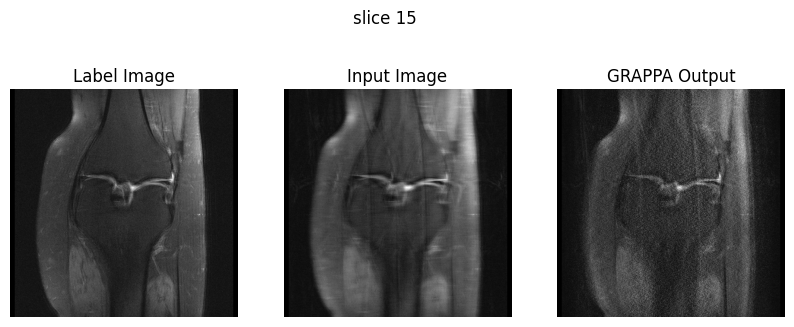

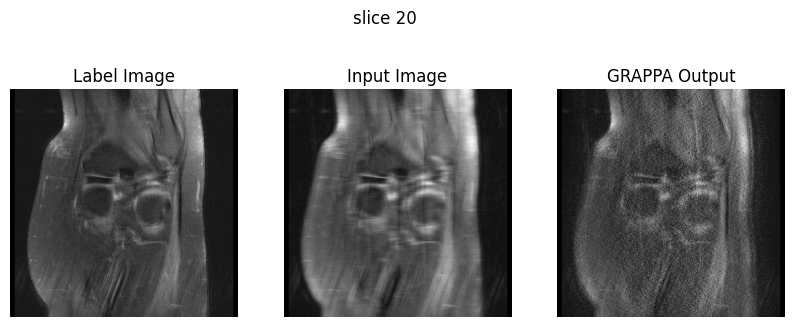

In [9]:
for slice_idx in range(0, image_label.shape[0], 5):
    plt.figure(figsize=(10, 4))
    plt.suptitle(f'slice {slice_idx}')

    ax = plt.subplot(1, 3, 1)
    plt.imshow(image_label[slice_idx], cmap='gray')
    ax.set_title('Label Image')
    ax.axis('off')

    ax = plt.subplot(1, 3, 2)
    plt.imshow(image_input[slice_idx], cmap='gray')
    ax.set_title('Input Image')
    ax.axis('off')

    ax = plt.subplot(1, 3, 3)
    plt.imshow(image_grappa[slice_idx], cmap='gray')
    ax.set_title('GRAPPA Output')
    ax.axis('off')

    plt.show()

In [10]:
image_f.close()

## Image data (knee, acc8)

acc8 (8배 가속) data도 파일 형식, key, shape 등은 acc4와 동일합니다. acc4 대비 undersampling이 더 심해 aliasing이 강하게 나타나는 점을 비교해 보세요.

In [11]:
in_dir = f"{DATA_DIR}/train/image/knee_acc8_1.h5"
image_f = h5py.File(in_dir)

image_grappa = image_f['image_grappa']
image_input = image_f['image_input']
image_label = image_f['image_label']

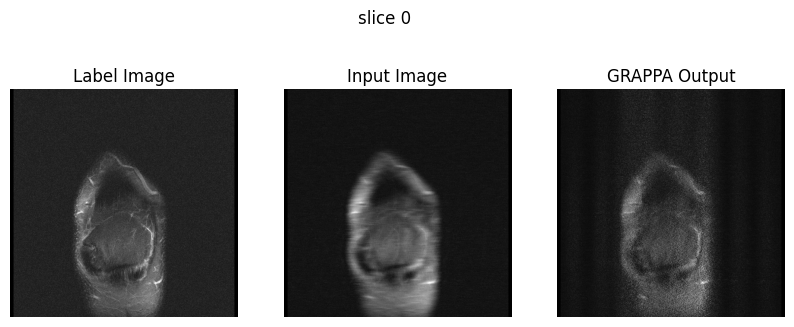

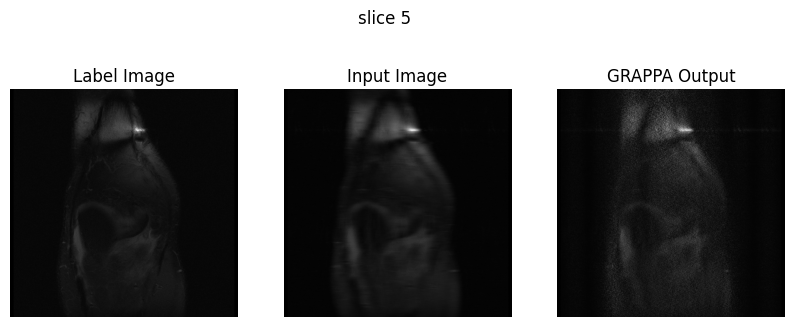

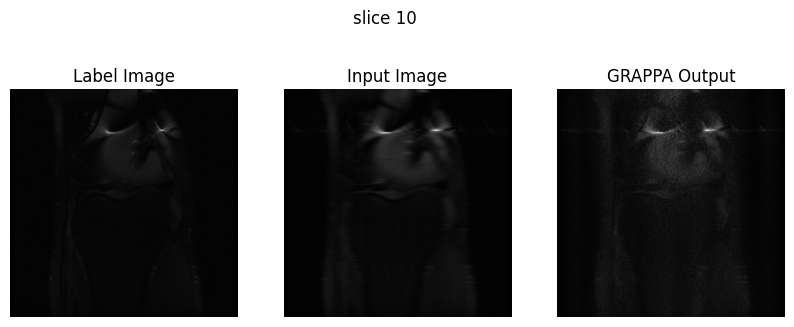

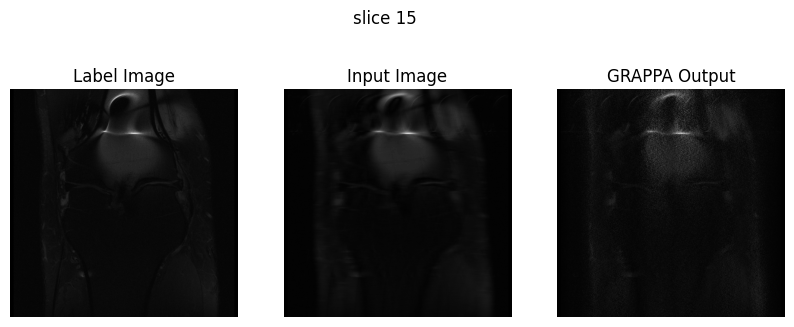

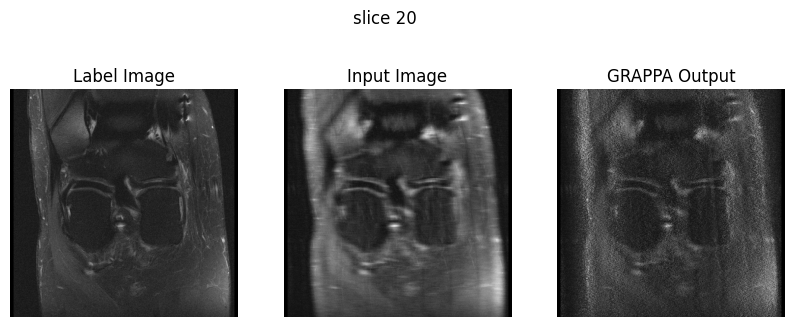

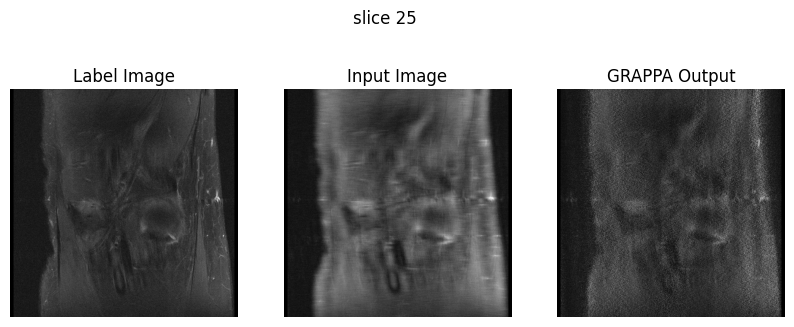

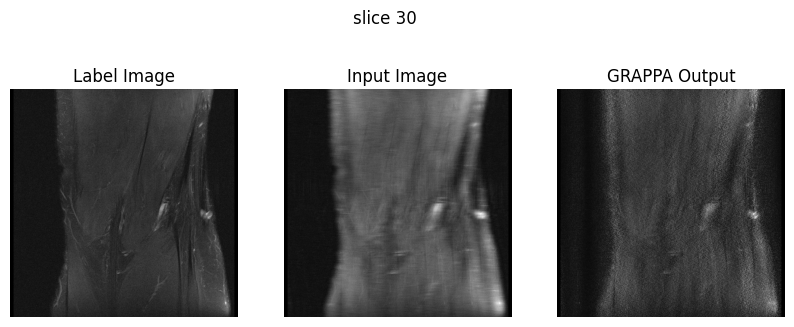

In [12]:
for slice_idx in range(0, image_label.shape[0], 5):
    plt.figure(figsize=(10, 4))
    plt.suptitle(f'slice {slice_idx}')

    ax = plt.subplot(1, 3, 1)
    plt.imshow(image_label[slice_idx], cmap='gray')
    ax.set_title('Label Image')
    ax.axis('off')

    ax = plt.subplot(1, 3, 2)
    plt.imshow(image_input[slice_idx], cmap='gray')
    ax.set_title('Input Image')
    ax.axis('off')

    ax = plt.subplot(1, 3, 3)
    plt.imshow(image_grappa[slice_idx], cmap='gray')
    ax.set_title('GRAPPA Output')
    ax.axis('off')

    plt.show()

In [13]:
image_f.close()

## Annotation (BBox) 시각화

일부 image data file은 병변 위치를 나타내는 bounding box annotation을 포함합니다.
annotation은 h5 file의 `annotations` attribute에 JSON 문자열로 저장되어 있으며, 구조는 다음과 같습니다.

```
{"슬라이스번호": [{"x", "y", "width", "height", "label"}, ...], ...}
```

좌표는 이미 image (384 x 384) 공간 기준이므로, `image_label` 위에 그대로 사각형을 그리면 됩니다.

annotated slices: ['13', '14', '17']


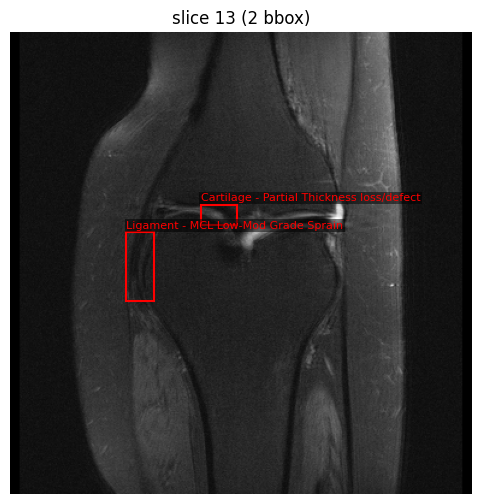

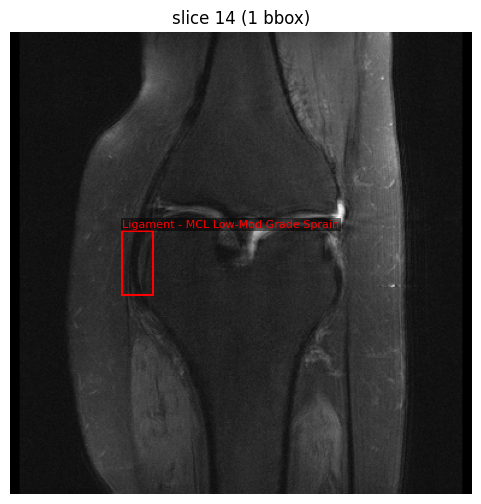

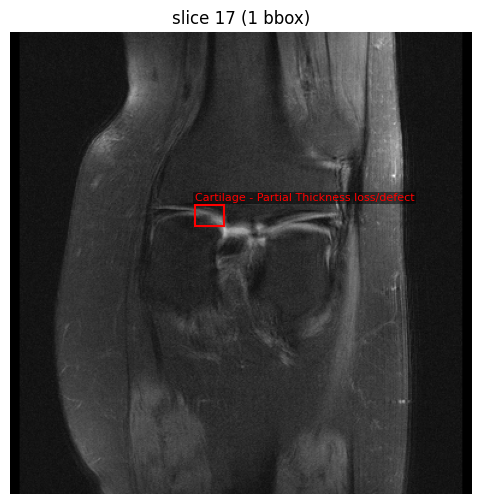

In [14]:
import json
import matplotlib.patches as patches

# annotations attribute를 포함한 image h5 file
in_dir = f"{DATA_DIR}/train/image/knee_acc4_1.h5"
image_f = h5py.File(in_dir, "r")

annotations = json.loads(image_f.attrs.get("annotations", "{}"))
image_label = image_f["image_label"]
print("annotated slices:", sorted(annotations.keys(), key=int))

for slice_key in sorted(annotations.keys(), key=int):
    slice_idx = int(slice_key)
    boxes = annotations[slice_key]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_label[slice_idx], cmap="gray")
    ax.set_title(f"slice {slice_idx} ({len(boxes)} bbox)")
    ax.axis("off")

    for box in boxes:
        rect = patches.Rectangle(
            (box["x"], box["y"]),
            box["width"],
            box["height"],
            linewidth=1.5,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            box["x"],
            box["y"] - 3,
            box["label"].strip(),
            color="red",
            fontsize=8,
            bbox=dict(facecolor="black", alpha=0.5, pad=1, edgecolor="none"),
        )
    plt.show()

image_f.close()